In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np

from gacha_model import COND_PROB_5_STAR, COND_PROB_6_STAR

random.seed(0)

In [14]:
class 明日方舟抽卡:
    def __init__(self):
        self.已抽次数: int = 0
        self.六星水位: int = 0
        self.五星水位: int = 0
        self.已抽出五星及以上: bool = False
        self.已抽出甲: bool = False  # 甲是限定6星干员
        self.已抽出乙: bool = False  # 乙和丙是限定5星干员
        self.已抽出丙: bool = False

    def 干员池抽一次(self):
        self.已抽次数 += 1
        if not self.已抽出甲 and self.已抽次数 == 120:
            result = "甲"
        else:
            六星概率 = COND_PROB_6_STAR[self.六星水位]
            五星概率 = COND_PROB_5_STAR[self.五星水位]
            r = random.random()
            if r < 六星概率:  # 6星
                self.已抽出五星及以上 = True
                self.六星水位 = 0
                self.五星水位 = 0
                if random.random() < 1/2:  # 甲
                    result = "甲"
                else:  # 其他6星干员
                    result = "其他6星"
            elif r < 六星概率 + 五星概率 or (self.已抽次数 == 10 and not self.已抽出五星及以上):  # 5星
                self.已抽出五星及以上 = True
                self.五星水位 = 0
                self.六星水位 += 1
                if not self.已抽出乙 and self.已抽出丙:
                    result = "乙"
                elif not self.已抽出丙 and self.已抽出乙:
                    result = "丙"
                else:
                    s = random.random()
                    if s < 1/4:
                        result = "乙"
                    elif s < 1/2:
                        result = "丙"
                    else:
                        result = "其他5星"
            else:  # 4星或以下
                self.六星水位 += 1
                self.五星水位 += 1
                result = "4星或以下"

        if result == "甲":
            self.已抽出甲 = True
        elif result == "乙":
            self.已抽出乙 = True
        elif result == "丙":
            self.已抽出丙 = True
        return result

    def 抽齐甲乙丙(self):
        while not (self.已抽出甲 and self.已抽出乙 and self.已抽出丙):
            self.干员池抽一次()
        return self.已抽次数


def 模拟(函数, 次数):
    结果 = [函数() for _ in range(次数)]
    分布列 = np.bincount(结果) / 次数
    return 分布列


def 函数():
    return 明日方舟抽卡().抽齐甲乙丙()


次数 = 2000000
分布列 = 模拟(函数, 次数)
print(分布列)

[0.00000e+00 0.00000e+00 0.00000e+00 1.04000e-04 2.71000e-04 5.07000e-04
 8.39000e-04 1.18450e-03 1.50150e-03 1.81250e-03 2.26550e-03 2.69600e-03
 3.31150e-03 3.97000e-03 4.59250e-03 5.01450e-03 5.56100e-03 5.90800e-03
 6.30550e-03 6.73850e-03 7.03850e-03 7.41350e-03 7.62250e-03 7.97450e-03
 8.29850e-03 8.52750e-03 8.76250e-03 8.88400e-03 9.22100e-03 9.31250e-03
 9.51300e-03 9.61700e-03 9.62400e-03 9.74600e-03 9.83500e-03 9.78850e-03
 9.80000e-03 9.71600e-03 9.59750e-03 9.62250e-03 9.57750e-03 9.51700e-03
 9.31300e-03 9.27750e-03 9.28700e-03 9.12850e-03 9.04900e-03 8.84050e-03
 8.71000e-03 8.51700e-03 8.58900e-03 1.16095e-02 1.45205e-02 1.70325e-02
 1.89815e-02 2.04545e-02 2.11075e-02 2.11570e-02 2.06180e-02 1.97610e-02
 1.81815e-02 1.64935e-02 1.50260e-02 1.34315e-02 1.19145e-02 1.04750e-02
 9.36450e-03 8.54350e-03 7.85900e-03 7.22850e-03 6.91250e-03 6.58600e-03
 6.27450e-03 6.09450e-03 5.94150e-03 5.86600e-03 5.70050e-03 5.66550e-03
 5.57850e-03 5.46350e-03 5.36250e-03 5.11400e-03 5.

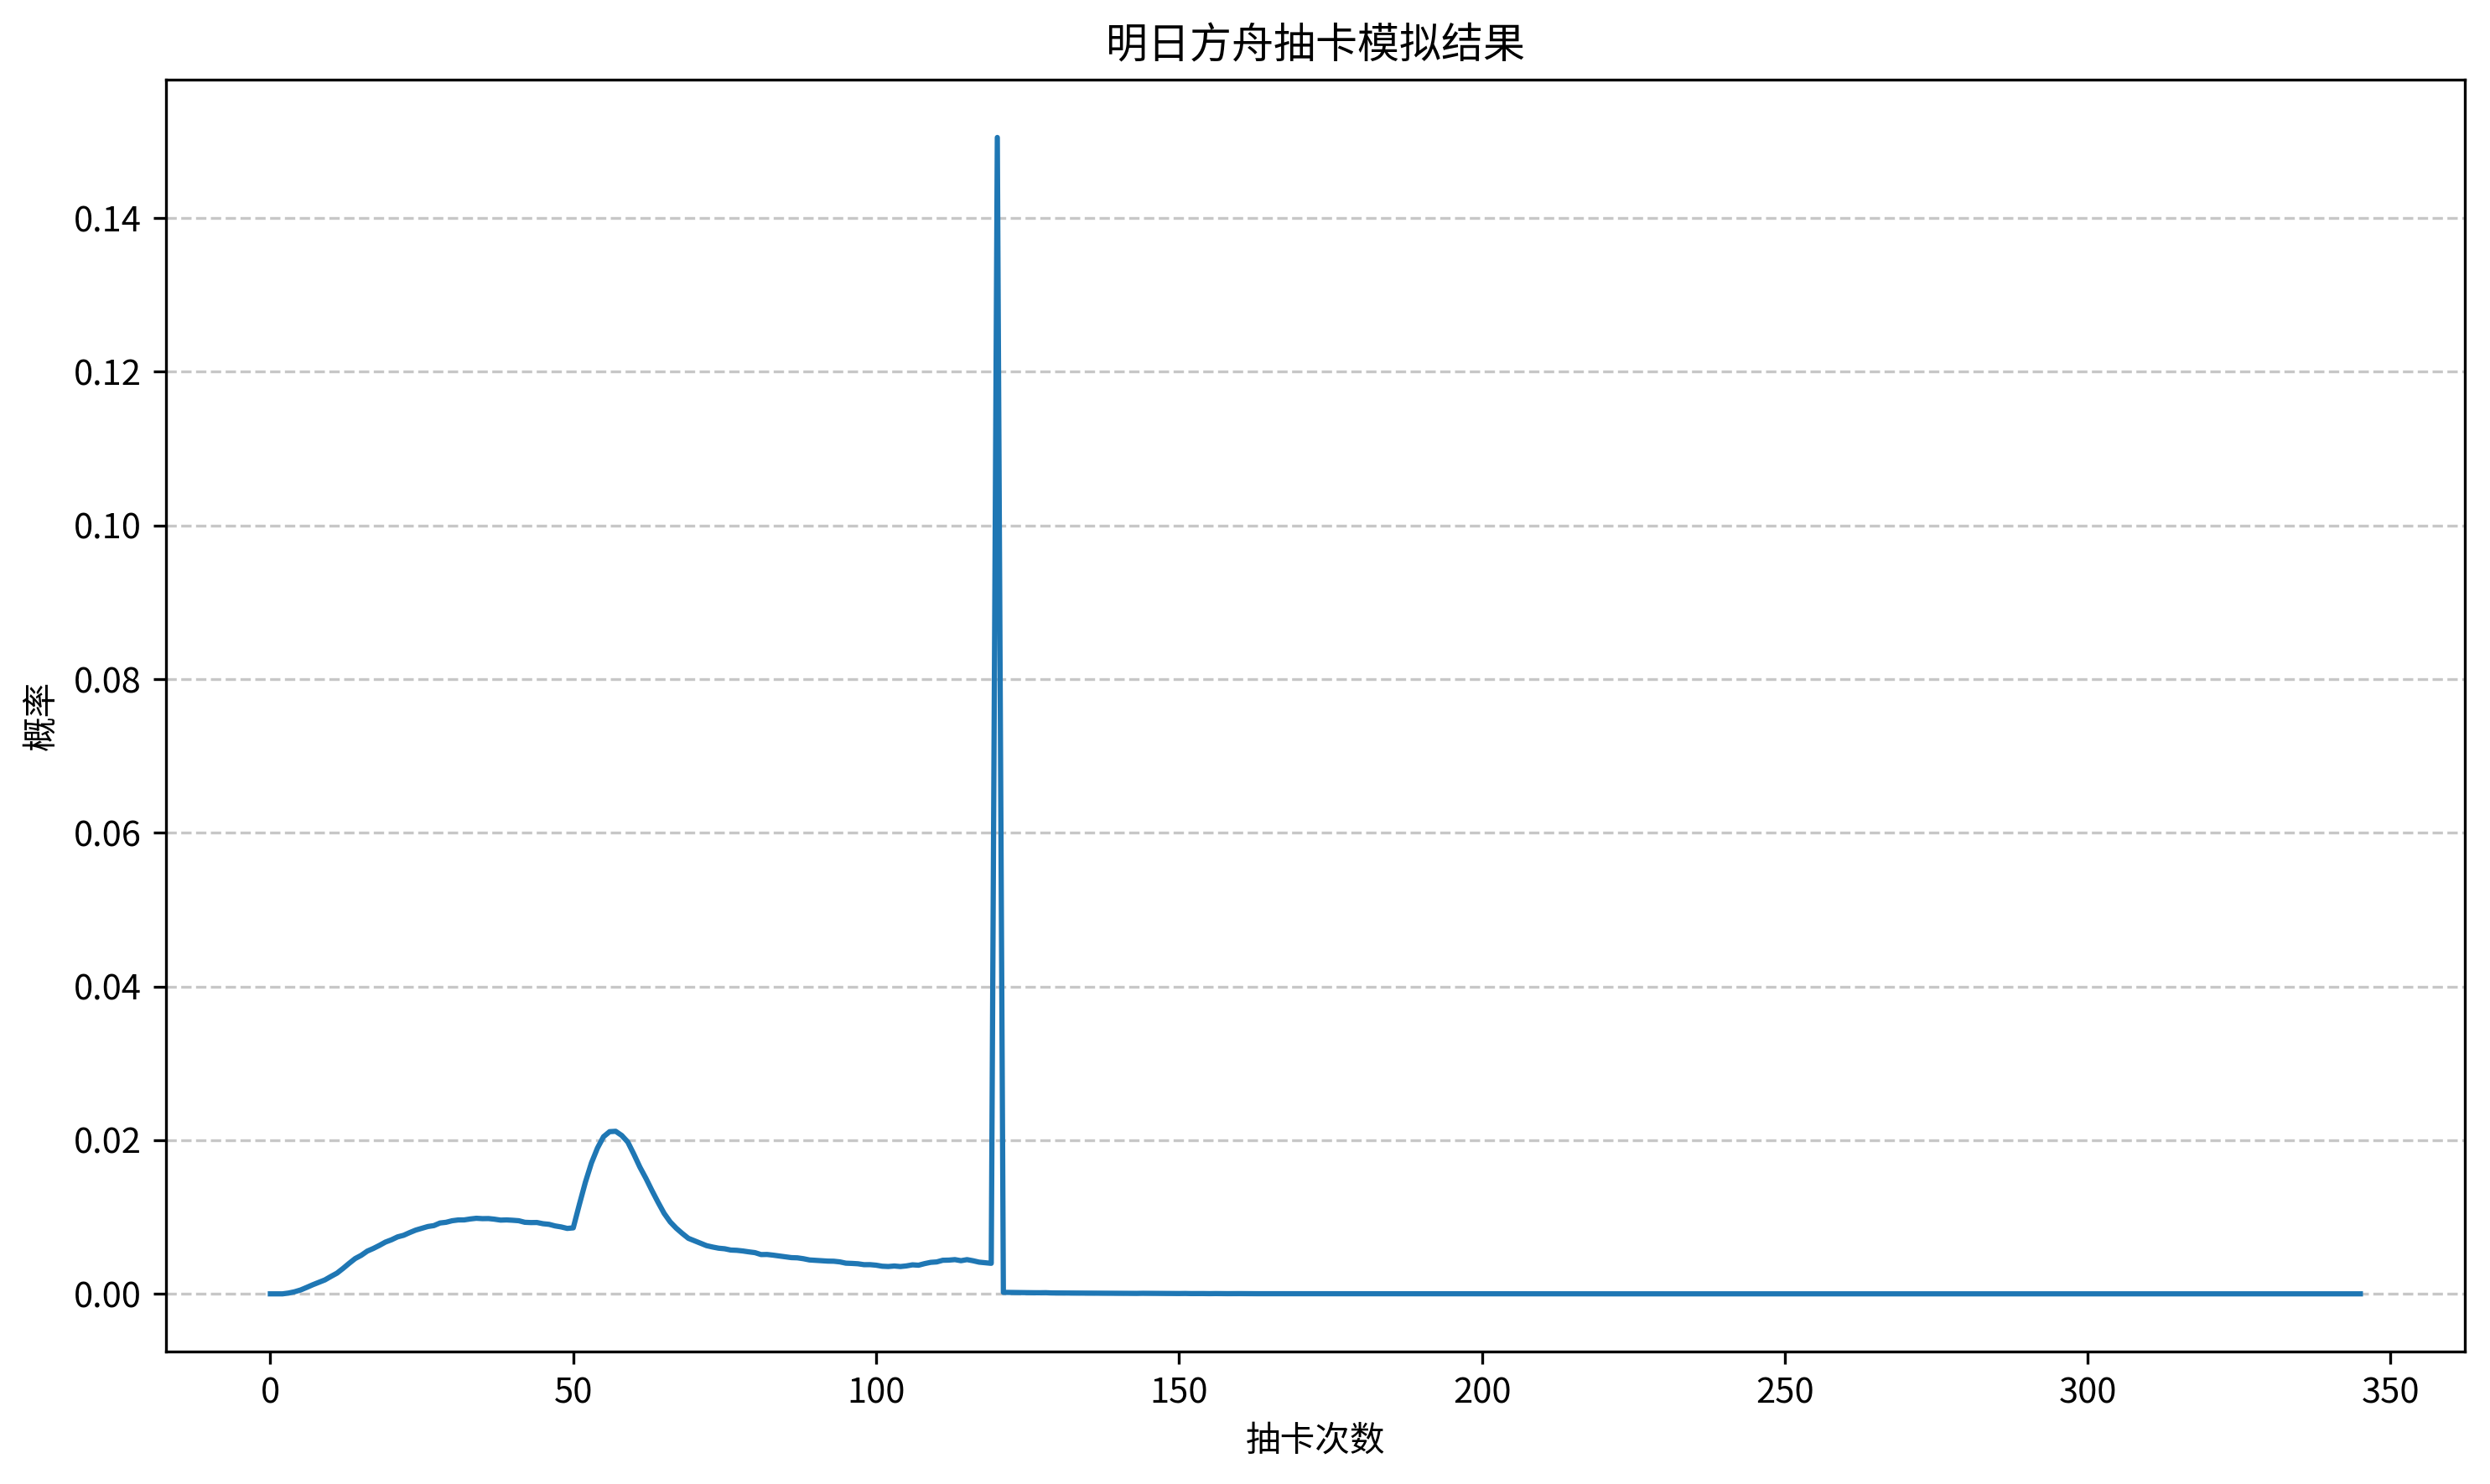

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(分布列)
plt.xlabel('抽卡次数')
plt.ylabel('概率')
plt.title('明日方舟抽卡模拟结果')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

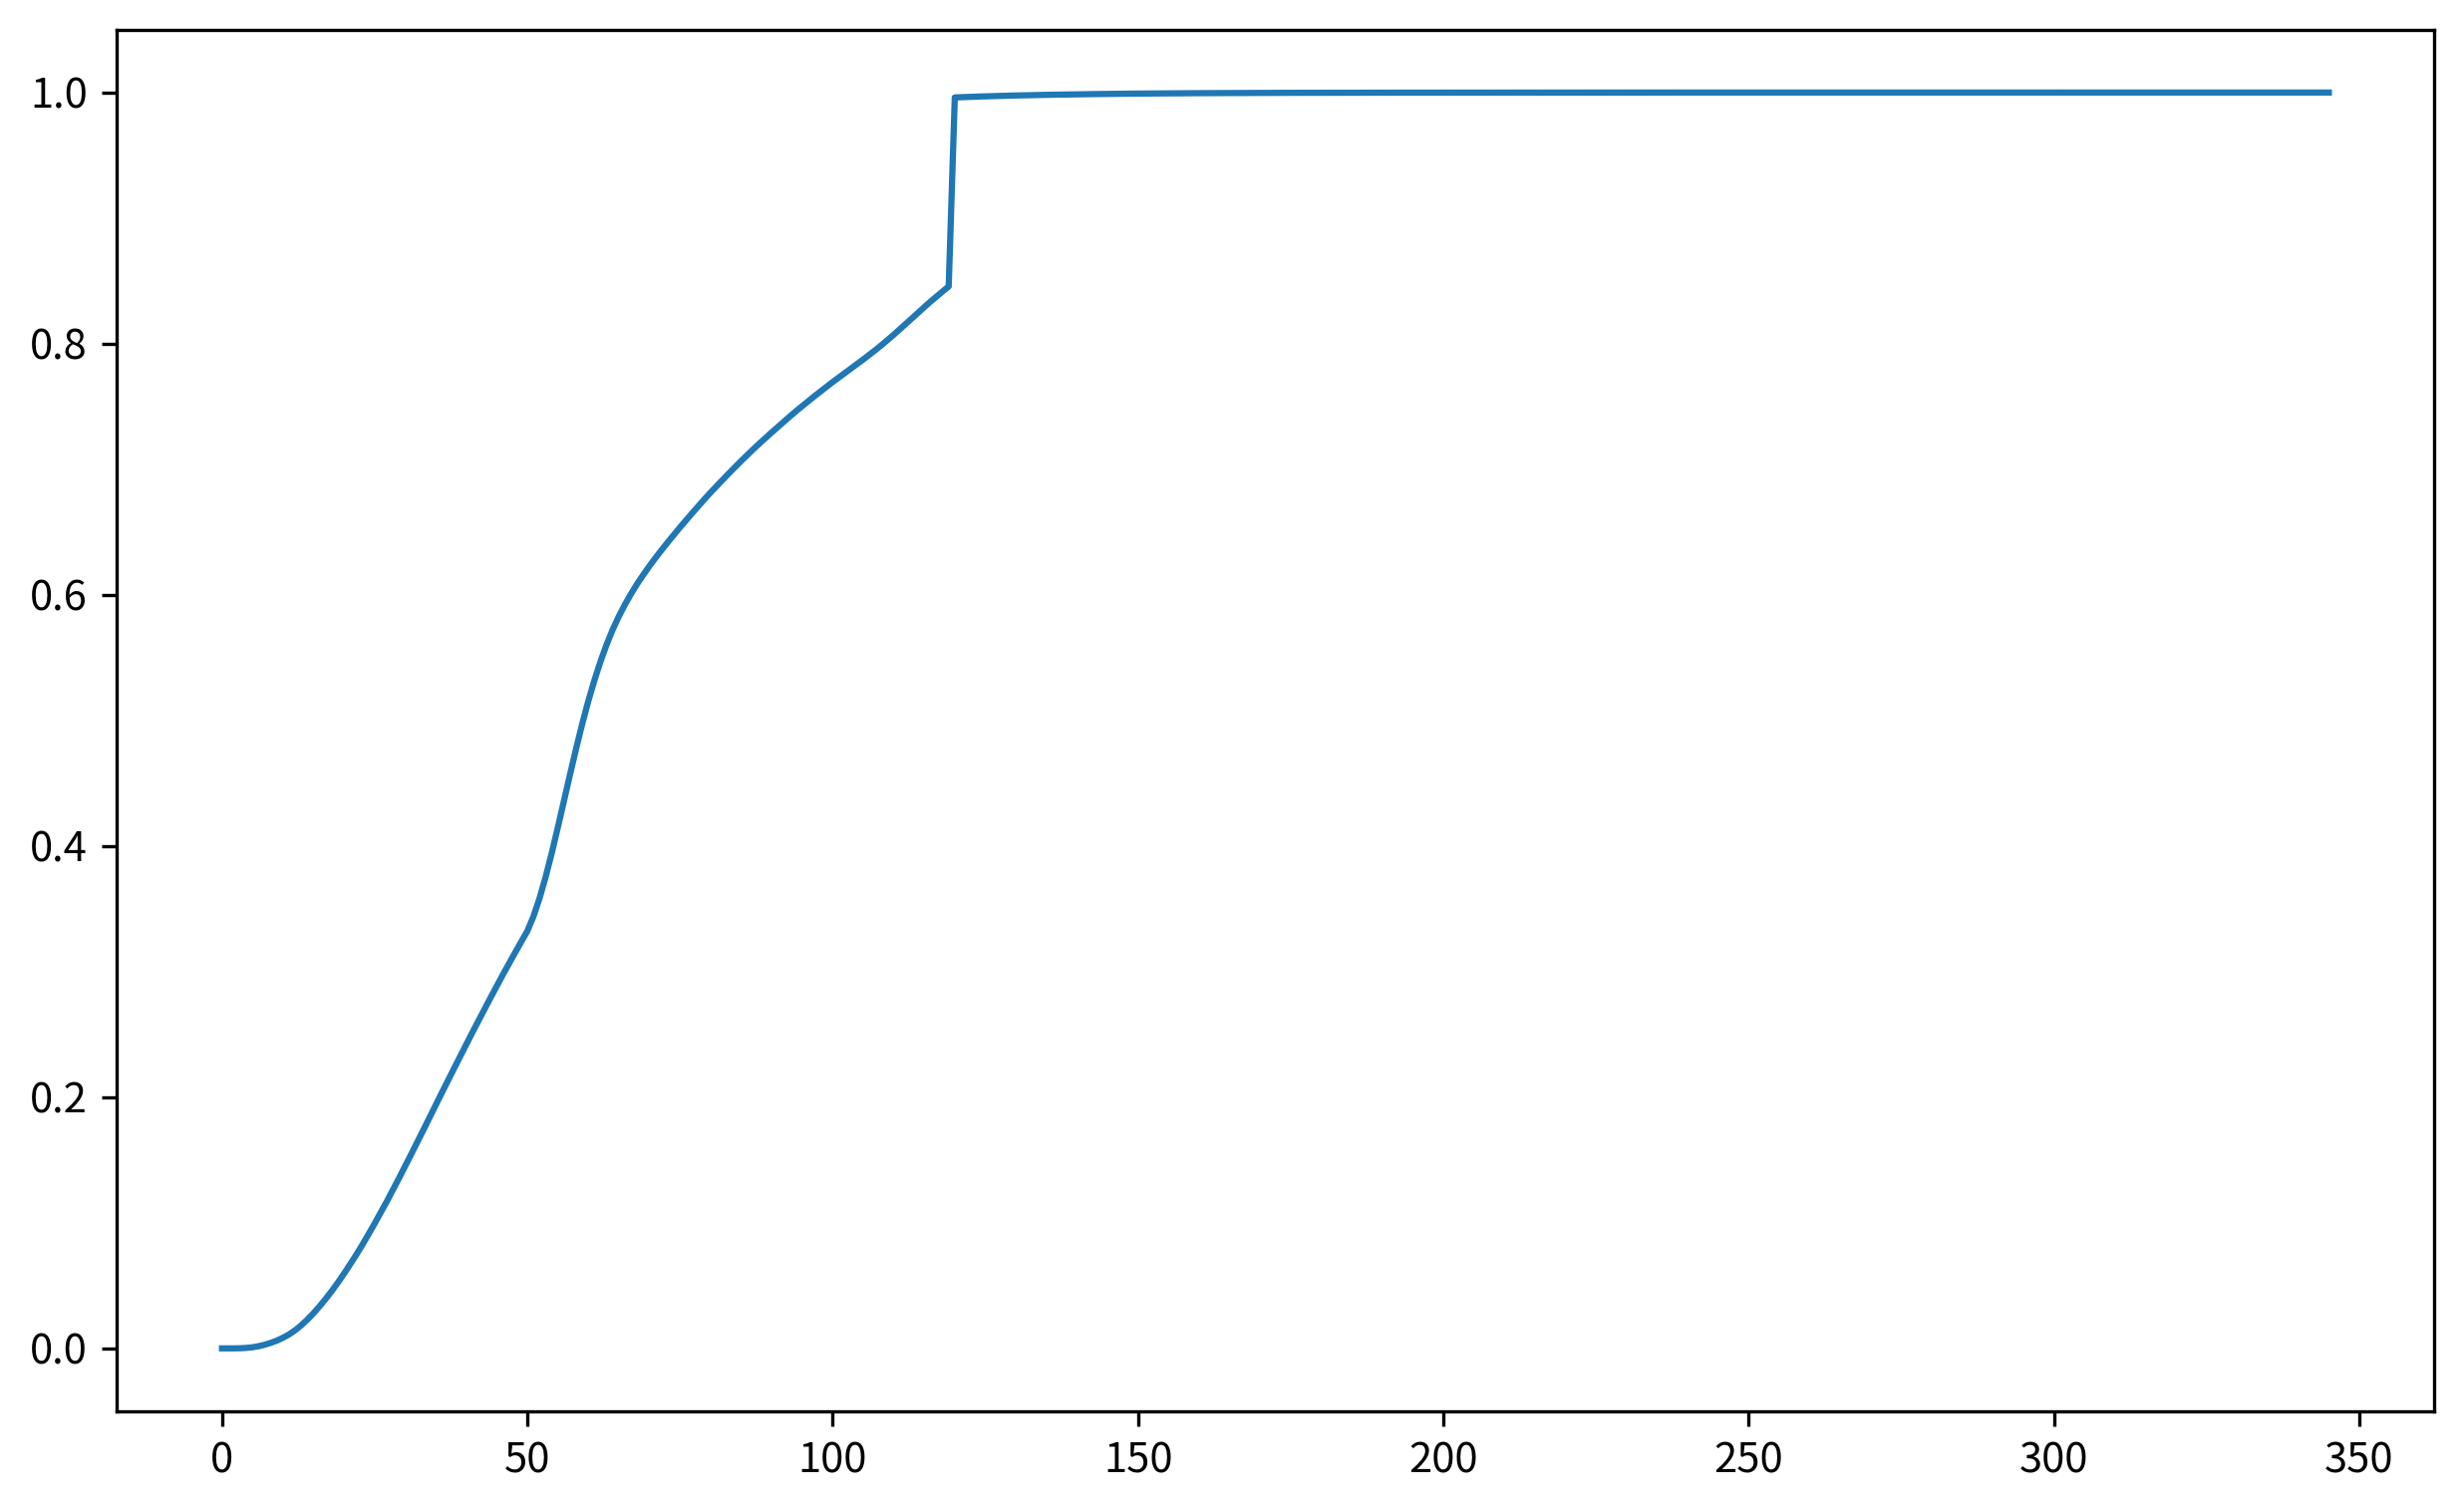

In [20]:
cdf = np.cumsum(分布列)
plt.figure(figsize=(10, 6))
plt.plot(cdf)

In [22]:
cdf.round(4).tolist()

[0.0,
 0.0,
 0.0,
 0.0001,
 0.0004,
 0.0009,
 0.0017,
 0.0029,
 0.0044,
 0.0062,
 0.0085,
 0.0112,
 0.0145,
 0.0185,
 0.0231,
 0.0281,
 0.0336,
 0.0395,
 0.0458,
 0.0526,
 0.0596,
 0.067,
 0.0747,
 0.0826,
 0.0909,
 0.0995,
 0.1082,
 0.1171,
 0.1263,
 0.1356,
 0.1452,
 0.1548,
 0.1644,
 0.1741,
 0.184,
 0.1938,
 0.2036,
 0.2133,
 0.2229,
 0.2325,
 0.2421,
 0.2516,
 0.2609,
 0.2702,
 0.2795,
 0.2886,
 0.2976,
 0.3065,
 0.3152,
 0.3237,
 0.3323,
 0.3439,
 0.3584,
 0.3755,
 0.3944,
 0.4149,
 0.436,
 0.4572,
 0.4778,
 0.4975,
 0.5157,
 0.5322,
 0.5472,
 0.5607,
 0.5726,
 0.5831,
 0.5924,
 0.601,
 0.6088,
 0.6161,
 0.623,
 0.6296,
 0.6358,
 0.6419,
 0.6479,
 0.6537,
 0.6594,
 0.6651,
 0.6707,
 0.6761,
 0.6815,
 0.6866,
 0.6917,
 0.6968,
 0.7017,
 0.7065,
 0.7113,
 0.716,
 0.7205,
 0.7249,
 0.7293,
 0.7336,
 0.7379,
 0.7421,
 0.7463,
 0.7503,
 0.7542,
 0.7581,
 0.7619,
 0.7657,
 0.7695,
 0.7731,
 0.7766,
 0.7802,
 0.7838,
 0.7874,
 0.7912,
 0.7949,
 0.7989,
 0.803,
 0.8071,
 0.8115,
 0.8159,